In [2]:
!pip install h5py matplotlib numpy tensorflow scikit-learn seaborn -q
print("All Libraries are installed!")

All Libraries are installed!


In [3]:
# dataset
!wget -q "https://astro.utoronto.ca/~hleung/shared/Galaxy10/Galaxy10_DECals.h5" -O Galaxy10_DECals.h5
print("Dataset downloaded!")

Dataset downloaded!


In [5]:
import h5py
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 64
SPIRAL_CLASSES   = [5, 6, 7]
ELLIPTICAL_CLASS = [2]
IRREGULAR_CLASS  = [0]

print("Loading all data at once...")
with h5py.File('Galaxy10_DECals.h5', 'r') as f:
    all_images = f['images'][:]  # read everything at once
    all_labels = f['ans'][:]
print("Loaded!")

# Filter indices
mask = np.isin(all_labels, SPIRAL_CLASSES + ELLIPTICAL_CLASS + IRREGULAR_CLASS)
filtered_images = all_images[mask]
filtered_labels = all_labels[mask]

# Relabel
new_labels = np.zeros(len(filtered_labels), dtype=int)
new_labels[np.isin(filtered_labels, ELLIPTICAL_CLASS)] = 1
new_labels[np.isin(filtered_labels, IRREGULAR_CLASS)]  = 2

# Balance: 1000 per class
final_images, final_labels = [], []
for cls in range(3):
    idx = np.where(new_labels == cls)[0][:1000]
    final_images.append(filtered_images[idx])
    final_labels.append(np.full(len(idx), cls))

final_images = np.concatenate(final_images)
final_labels = np.concatenate(final_labels)

print("Resizing...")
X = np.array([cv2.resize(img, (IMG_SIZE, IMG_SIZE)) for img in final_images])
X = X.astype('float32') / 255.0
y = final_labels

class_names = ['Spiral', 'Elliptical', 'Irregular']
print(f"\nTotal: {len(y)} images")
for i, name in enumerate(class_names):
    print(f"  {name}: {np.sum(y == i)}")

y_cat = to_categorical(y, num_classes=3)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print(f"\nTrain:      {X_train.shape[0]} images")
print(f"Validation: {X_val.shape[0]} images")
print(f"Test:       {X_test.shape[0]} images")
print("\nAll done!")

Loading all data at once...
Loaded!
Resizing...

Total: 3000 images
  Spiral: 1000
  Elliptical: 1000
  Irregular: 1000

Train:      2167 images
Validation: 383 images
Test:       450 images

All done!


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation — create variations of training images
datagen = ImageDataGenerator(
    rotation_range=30,        # rotate up to 30 degrees (galaxies can be any angle)
    horizontal_flip=True,     # mirror horizontally
    vertical_flip=True,       # mirror vertically
    zoom_range=0.1,           # zoom in/out slightly
    width_shift_range=0.1,    # shift horizontally
    height_shift_range=0.1    # shift vertically
)

datagen.fit(X_train)

# Simpler model to prevent overfitting
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=40,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3737 - loss: 2.5686
Epoch 1: val_loss improved from None to 5.00392, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 162ms/step - accuracy: 0.3950 - loss: 1.5651 - val_accuracy: 0.3342 - val_loss: 5.0039
Epoch 2/40
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4778 - loss: 1.0469
Epoch 2: val_loss did not improve from 5.00392
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4712 - loss: 1.0304 - val_accuracy: 0.3342 - val_loss: 8.2976
Epoch 3/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4995 - loss: 0.9954
Epoch 3: val_loss did not improve from 5.00392
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5044 - loss: 0.9800 - val_accuracy: 0.3342 - val_loss: 8.9535
Epoch 4/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5481 - loss: 0.9421
Epoch 4: val_loss did not improve from 5.00392
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,428,811 (13.08 MB)

 Trainable params: 1,142,787 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,285,576 (8.72 MB)

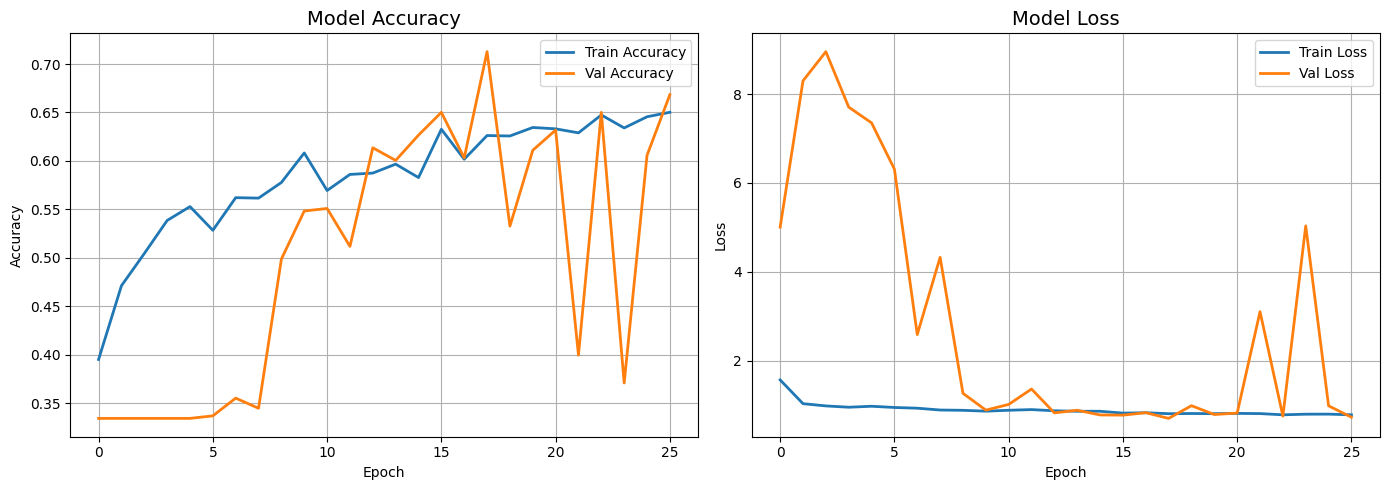

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step


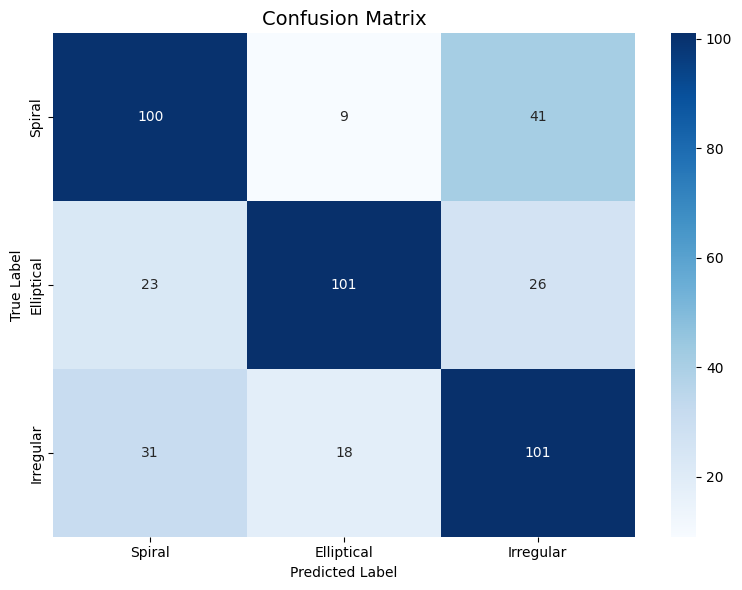


Classification Report:
              precision    recall  f1-score   support

      Spiral       0.65      0.67      0.66       150
  Elliptical       0.79      0.67      0.73       150
   Irregular       0.60      0.67      0.64       150

    accuracy                           0.67       450
   macro avg       0.68      0.67      0.67       450
weighted avg       0.68      0.67      0.67       450

Test Accuracy: 67.11%
Test Loss:     0.7946


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

class_names = ['Spiral', 'Elliptical', 'Irregular']

# ── 1. Accuracy & Loss curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# ── 2. Confusion Matrix ────────────────────────────────────────────────
y_pred_probs = model.predict(X_test)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test,       axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 3. Classification Report ───────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ── 4. Test Accuracy ───────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

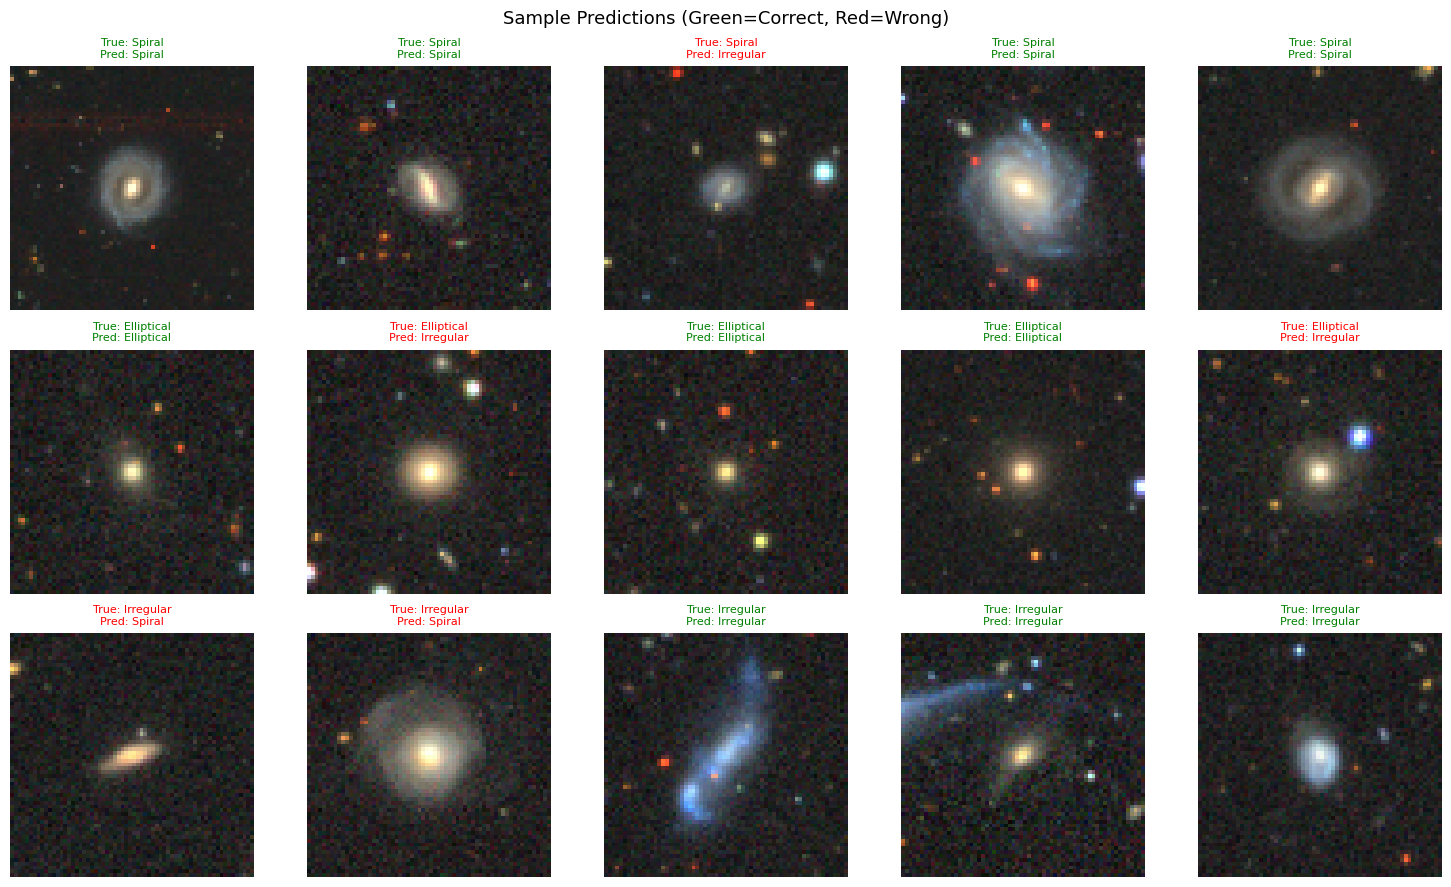

In [8]:
# Show sample predictions
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for cls_idx, cls_name in enumerate(class_names):
    cls_indices = np.where(y_true == cls_idx)[0][:5]
    for j, idx in enumerate(cls_indices):
        ax = axes[cls_idx][j]
        ax.imshow(X_test[idx])
        pred  = class_names[y_pred[idx]]
        true  = class_names[y_true[idx]]
        color = 'green' if pred == true else 'red'
        ax.set_title(f"True: {true}\nPred: {pred}",
                     color=color, fontsize=8)
        ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()